In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

ENDERECO_DADOS = \
r'C:/Users/renan.duarte/Documents/analise_dados_senac_2026.3/dados_bronze/'

In [2]:
try:
    print('Lendo arquivo parquet')

    hora_inicio = dt.datetime.now()
    # cria um plano de execução sobre o futuro df
    df_bf_exec_plan = pl.scan_parquet(
        ENDERECO_DADOS + 'bf.parquet'
    )
    df_cidades = pl.scan_csv(ENDERECO_DADOS 
                             + '14.CodigosMunic.csv',
                             separator=';')
    df_lazy = (
        df_bf_exec_plan.join(
            df_cidades,
            left_on='CÓDIGO MUNICÍPIO SIAFI',
            right_on='COD_SIAFI',
            how='left'
        ).select([pl.col('VALOR PARCELA'),
            pl.col('UF'),
            pl.col('MÊS COMPETÊNCIA'),
            pl.col('NOME')
            ]).with_columns(
                pl.col('MÊS COMPETÊNCIA')
                .cast(pl.Utf8)
                .str.strptime(pl.Date, format='%Y%m')
            )
    )
    hora_fim = dt.datetime.now()

    print(f'Tempo de Execução: {hora_fim-hora_inicio}')

except Exception as e:
    print(f'Erro ao obter dados parquet: {e}')

Lendo arquivo parquet
Tempo de Execução: 0:00:00.002571


In [3]:
# analise exploratoria basica
coluna_alvo = 'VALOR PARCELA'
df_analises = df_lazy.select(
    pl.col(coluna_alvo).mean().alias('Media'),
    pl.col(coluna_alvo).median().alias('Mediana/Q2'),
    pl.col(coluna_alvo).std().alias('Desvio_padrao'),
    pl.col(coluna_alvo).skew().alias('Assimetria'),
    pl.col(coluna_alvo).kurtosis().alias('Curtose'),
    (pl.col(coluna_alvo).mean() - 
     pl.col(coluna_alvo).median()).alias('delta_media_mediana'),
    pl.col(coluna_alvo).quantile(0.25).alias('Q1'),
    pl.col(coluna_alvo).quantile(0.75).alias('Q3')
).collect()

In [4]:
try:
    print('Preparando dados para visualização')

    df = df_lazy.collect()
    valores = np.array(df['VALOR PARCELA'])
    q1 = df_analises['Q1'][0]
    q3 = df_analises['Q3'][0]
    iqr = q3 - q1

    lim_sup = q3 + 1.5 * iqr
    lim_inf = q1 - 1.5 * iqr 
    outliers_sup = valores > lim_sup
    outliers_inf = valores < lim_inf

    total_outliers = len(outliers_inf) + len(outliers_sup)
    porcentagem_outliers = (total_outliers/len(valores))*100

except Exception as e:
    print(f'Erro na preparação dos dados: {e}')

Preparando dados para visualização


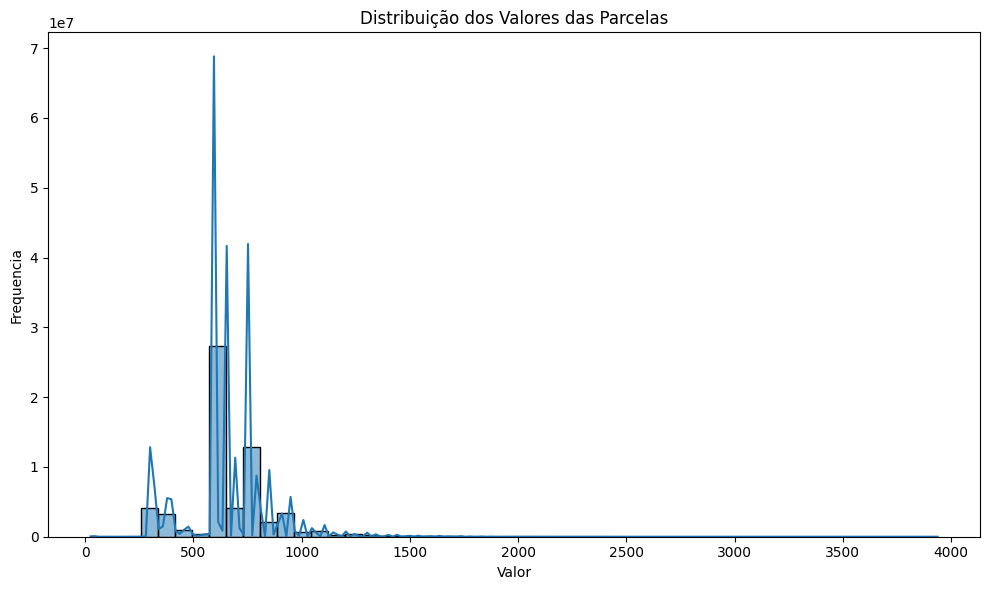

In [6]:
try:
    # histograma smooth
    plt.figure(figsize=(10, 6))
    sns.histplot(valores, bins=50, kde=True)
    plt.title('Distribuição dos Valores das Parcelas')
    plt.xlabel('Valor')
    plt.ylabel('Frequencia')
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f'Erro na visualização dos dados: {e}')

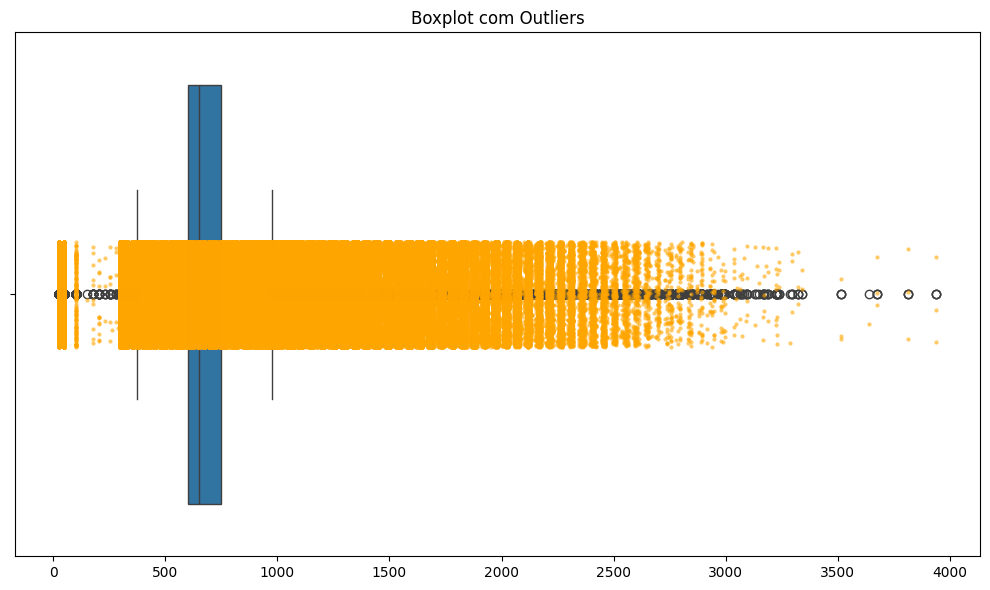

In [ ]:
# boxplot seaborn
plt.figure(figsize=(10, 6))
sns.boxplot(x=valores)
sns.stripplot(x=valores, color='orange', alpha=0.6, size=3)
plt.title('Boxplot com Outliers')
plt.tight_layout()
plt.show()

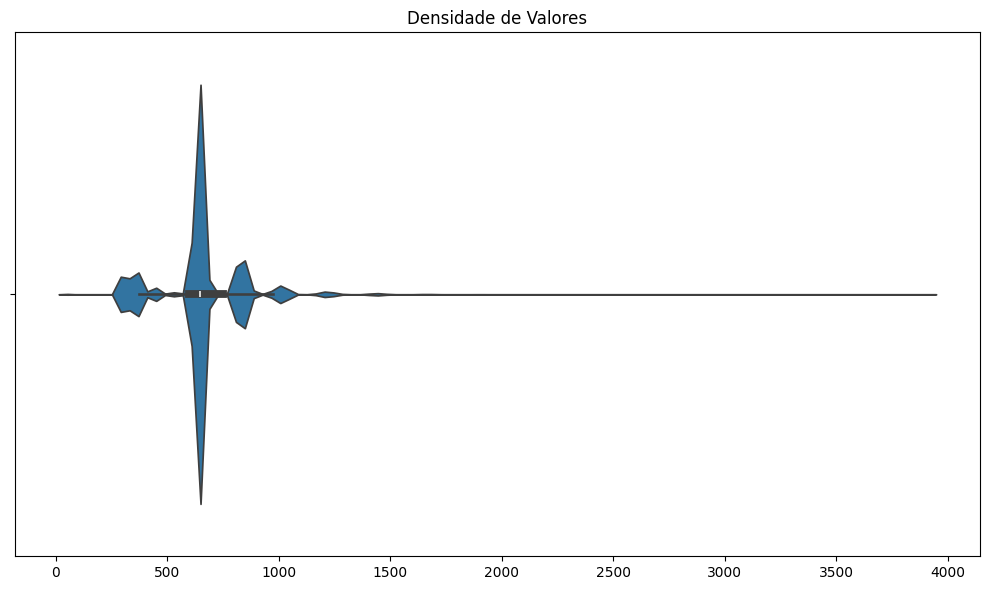

In [9]:
# Violino
plt.figure(figsize=(10,6))
sns.violinplot(x=valores)
plt.title('Densidade de Valores')
plt.tight_layout()
plt.show()

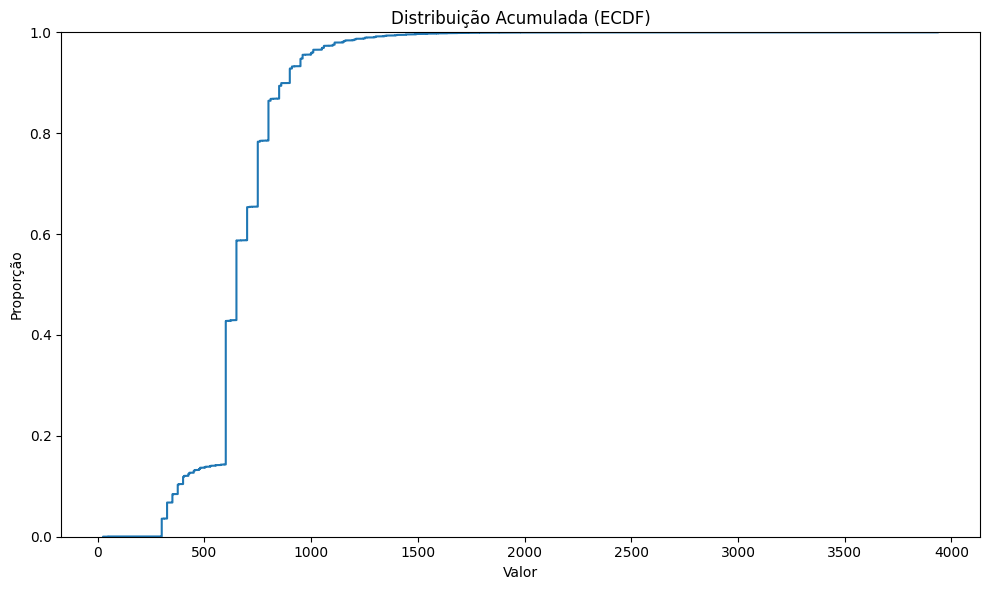

In [ ]:
#ECDF
plt.figure(figsize=(10, 6))
sns.ecdfplot(valores)
plt.title('Distribuição Acumulada (ECDF)')
plt.xlabel('Valor')
plt.ylabel('Proporção')
plt.tight_layout()
plt.show()